# Проект: прогнозирование стоимости медицинского страхования

## Основная задача

**Регрессия:** предсказать `charges` (стоимость страховки в USD) по 6 анкетным признакам.

## Модели

**Linear Regression**, **Ridge**, **Random Forest Regressor**.

## Метрики

MAE, RMSE, R², CV R² (5-fold).


## 1. Импорт библиотек

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, KFold, cross_val_score,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (9, 5)

## 2. Загрузка данных

In [2]:
df = pd.read_csv('insurance.csv').drop_duplicates().reset_index(drop=True)
print('Размер:', df.shape, 'пропусков:', df.isna().sum().sum())
df.head()

Размер: (1337, 7) пропусков: 0


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Описание целевой переменной и конструирование признаков

В EDA мы увидели:
- **`smoker` — главный предиктор.**
- сильное **взаимодействие `smoker × bmi`** (резкий рост `charges` у курящих с ожирением);
- **`age` влияет почти линейно** на charges, особенно у не курящих;
- слабые предикторы — `children`, `region`, `sex`.

Добавим признаки, явно кодирующие эти паттерны — это позволит линейным моделям ловить взаимодействия без перехода к деревьям.


In [3]:
def add_features(data: pd.DataFrame) -> pd.DataFrame:
    """Конструирование признаков на основе EDA."""
    data = data.copy()
    data['bmi_category'] = pd.cut(
        data['bmi'], bins=[0, 18.5, 25, 30, np.inf],
        labels=['underweight', 'normal', 'overweight', 'obese'],
    )
    data['age_group'] = pd.cut(
        data['age'], bins=[17, 30, 45, 60, np.inf],
        labels=['18-30', '31-45', '46-60', '60+'],
    )
    data['smoker_bin']   = (data['smoker'] == 'yes').astype(int)
    data['smoker_bmi']   = data['smoker_bin'] * data['bmi']
    data['smoker_age']   = data['smoker_bin'] * data['age']
    data['obese_smoker'] = ((data['bmi'] >= 30) & (data['smoker'] == 'yes')).astype(int)
    data['has_children'] = (data['children'] > 0).astype(int)
    return data

df_fe = add_features(df)
print('Размер после feature engineering:', df_fe.shape)
df_fe.head()

Размер после feature engineering: (1337, 14)


,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group,smoker_bin,smoker_bmi,smoker_age,obese_smoker,has_children
0,19,female,27.900,0,yes,southwest,16884.92400,overweight,18-30,1,27.9,19,0,0
1,18,male,33.770,1,no,southeast,1725.55230,obese,18-30,0,0.0,0,0,1
2,28,male,33.000,3,no,southeast,4449.46200,obese,18-30,0,0.0,0,0,1
3,33,male,22.705,0,no,northwest,21984.47061,normal,31-45,0,0.0,0,0,0
4,32,male,28.880,0,no,northwest,3866.85520,overweight,31-45,0,0.0,0,0,0


## 4. Функции для препроцессинга и оценки моделей

`ColumnTransformer` применит к числовым признакам стандартизацию, к категориальным — OneHot. Всё внутри `Pipeline`, чтобы исключить leakage между train и test.


In [4]:
def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    num = X.select_dtypes(include=[np.number]).columns.tolist()
    cat = X.select_dtypes(exclude=[np.number]).columns.tolist()
    return ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc',  StandardScaler())]), num),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat),
    ])

def eval_regression(name, pipe, X_tr, y_tr, X_te, y_te, cv):
    cv_r2 = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring='r2').mean()
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    return {
        'Model': name,
        'MAE':   mean_absolute_error(y_te, pred),
        'RMSE':  np.sqrt(mean_squared_error(y_te, pred)),
        'R2':    r2_score(y_te, pred),
        'CV_R2': cv_r2,
    }, pipe

## 5. Постановка задачи регрессии

Цель — предсказать `charges` (USD) по 13 признакам (6 исходных + 7 инженерных).

Метрики:
- **MAE** — средняя ошибка прогноза в долларах;
- **RMSE** — ошибка с усиленным штрафом за крупные промахи;
- **R²** — доля объяснённой вариации `charges`;
- **CV R²** — устойчивая 5-fold кросс-валидированная оценка R² на train.


## 6. Train-test split

In [5]:
target_reg = 'charges'
features_reg = [c for c in df_fe.columns if c != target_reg]
X_reg = df_fe[features_reg]
y_reg = df_fe[target_reg]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE,
)
print('Train:', X_train_reg.shape, 'Test:', X_test_reg.shape)
print(f'Mean y_train: {y_train_reg.mean():.1f},  Mean y_test: {y_test_reg.mean():.1f}')

Train: (1069, 13) Test: (268, 13)
Mean y_train: 13030.2,  Mean y_test: 14272.0


## 7. Обучение регрессионных моделей

Обучаем три модели:

1. **Linear Regression** — без регуляризации, baseline линейной модели.
2. **Ridge** — линейная регрессия с L2-регуляризацией; гиперпараметр `alpha` подбираем GridSearchCV.
3. **Random Forest Regressor** — нелинейный ансамбль из 300 деревьев; ключевые гиперпараметры тоже подбираем GridSearchCV.


In [6]:
preprocessor_reg = make_preprocessor(X_train_reg)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- 1) Linear Regression (без гиперпараметров) ---
lin_pipe = Pipeline([('prep', preprocessor_reg), ('model', LinearRegression())])
res_lin, lin_pipe = eval_regression('Linear Regression', lin_pipe,
                                    X_train_reg, y_train_reg, X_test_reg, y_test_reg, cv)

# --- 2) Ridge с GridSearchCV ---
ridge_pipe = Pipeline([('prep', preprocessor_reg), ('model', Ridge(random_state=RANDOM_STATE))])
ridge_grid = {'model__alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]}
gs_ridge = GridSearchCV(ridge_pipe, ridge_grid, cv=cv, scoring='r2', n_jobs=-1)
gs_ridge.fit(X_train_reg, y_train_reg)
print('Ridge best params:', gs_ridge.best_params_)
ridge_pred = gs_ridge.predict(X_test_reg)
res_ridge = {
    'Model': 'Ridge',
    'MAE':   mean_absolute_error(y_test_reg, ridge_pred),
    'RMSE':  np.sqrt(mean_squared_error(y_test_reg, ridge_pred)),
    'R2':    r2_score(y_test_reg, ridge_pred),
    'CV_R2': gs_ridge.best_score_,
}

# --- 3) Random Forest с GridSearchCV ---
rf_pipe = Pipeline([('prep', preprocessor_reg),
                    ('model', RandomForestRegressor(random_state=RANDOM_STATE))])
rf_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 8, 14],
    'model__min_samples_leaf': [1, 2, 4],
}
gs_rf = GridSearchCV(rf_pipe, rf_grid, cv=cv, scoring='r2', n_jobs=-1)
gs_rf.fit(X_train_reg, y_train_reg)
print('RF best params:', gs_rf.best_params_)
rf_pred = gs_rf.predict(X_test_reg)
res_rf = {
    'Model': 'Random Forest',
    'MAE':   mean_absolute_error(y_test_reg, rf_pred),
    'RMSE':  np.sqrt(mean_squared_error(y_test_reg, rf_pred)),
    'R2':    r2_score(y_test_reg, rf_pred),
    'CV_R2': gs_rf.best_score_,
}

best_regression_models = {
    'Linear Regression': lin_pipe,
    'Ridge': gs_ridge.best_estimator_,
    'Random Forest': gs_rf.best_estimator_,
}
regression_results_df = pd.DataFrame([res_lin, res_ridge, res_rf])
regression_results_df.round(3)

Ridge best params: {'model__alpha': 5.0}


RF best params: {'model__max_depth': 8, 'model__min_samples_leaf': 4, 'model__n_estimators': 400}


,Model,MAE,RMSE,R2,CV_R2
0,Linear Regression,2266.515,4145.692,0.906,0.850
1,Ridge,2273.136,4140.505,0.907,0.850
2,Random Forest,2405.145,4316.300,0.899,0.841


## 8. Сравнение регрессионных моделей

In [7]:
regression_results_df_sorted = regression_results_df.sort_values('MAE').reset_index(drop=True)
regression_results_df_sorted.round(3)

,Model,MAE,RMSE,R2,CV_R2
0,Linear Regression,2266.515,4145.692,0.906,0.850
1,Ridge,2273.136,4140.505,0.907,0.850
2,Random Forest,2405.145,4316.300,0.899,0.841


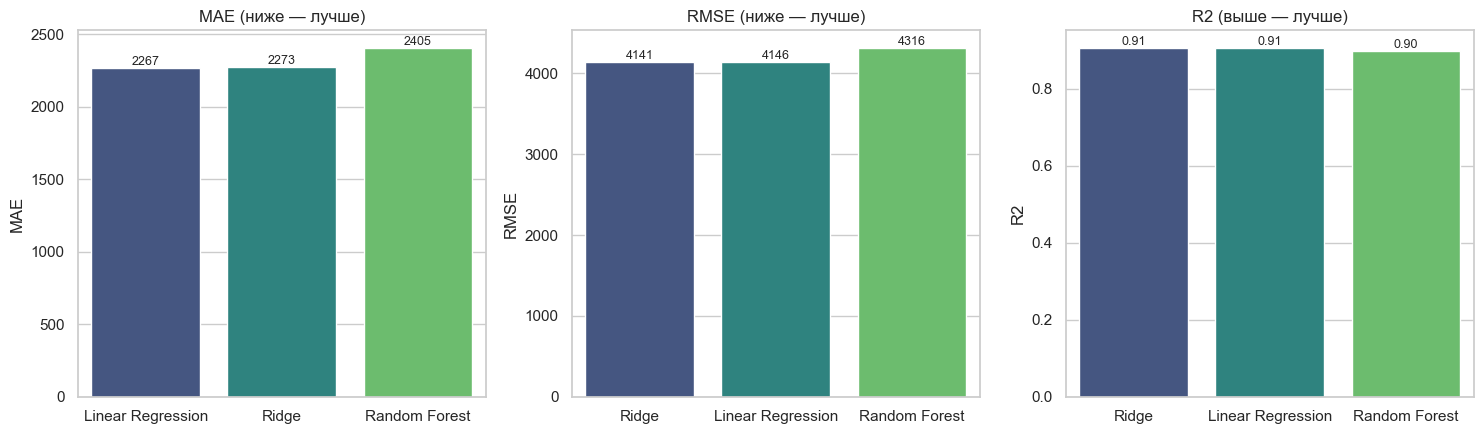

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (metric, lower_better) in zip(axes, [('MAE', True), ('RMSE', True), ('R2', False)]):
    order = regression_results_df_sorted.sort_values(metric, ascending=lower_better)
    sns.barplot(data=order, x='Model', y=metric, ax=ax, palette='viridis')
    ax.set_title(f"{metric} ({'ниже — лучше' if lower_better else 'выше — лучше'})")
    ax.set_xlabel('')
    for i, v in enumerate(order[metric].values):
        ax.text(i, v, f'{v:.2f}' if metric == 'R2' else f'{v:.0f}',
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

## 9. Анализ лучшей регрессионной модели

Лучшая модель: Linear Regression


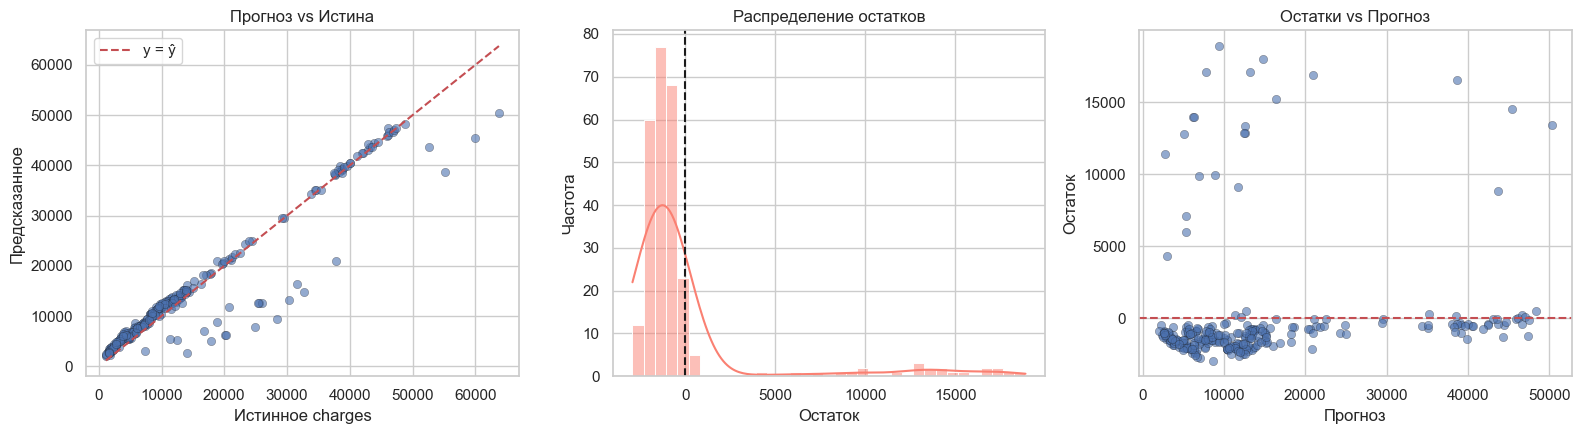

Mean residual: -57.51
Std residual : 4153.05


In [9]:
best_reg_name = regression_results_df_sorted.iloc[0]['Model']
best_reg_pipe = best_regression_models[best_reg_name]
best_reg_pred = best_reg_pipe.predict(X_test_reg)
print('Лучшая модель:', best_reg_name)

residuals = y_test_reg - best_reg_pred
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(y_test_reg, best_reg_pred, alpha=0.6, edgecolor='k', linewidth=0.3)
lims = [min(y_test_reg.min(), best_reg_pred.min()),
        max(y_test_reg.max(), best_reg_pred.max())]
axes[0].plot(lims, lims, 'r--', label='y = ŷ')
axes[0].set_xlabel('Истинное charges'); axes[0].set_ylabel('Предсказанное')
axes[0].set_title('Прогноз vs Истина'); axes[0].legend()

sns.histplot(residuals, bins=35, kde=True, ax=axes[1], color='salmon')
axes[1].axvline(0, color='k', linestyle='--')
axes[1].set_xlabel('Остаток'); axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение остатков')

axes[2].scatter(best_reg_pred, residuals, alpha=0.6, edgecolor='k', linewidth=0.3)
axes[2].axhline(0, color='r', linestyle='--')
axes[2].set_xlabel('Прогноз'); axes[2].set_ylabel('Остаток')
axes[2].set_title('Остатки vs Прогноз')

plt.tight_layout(); plt.show()
print(f'Mean residual: {residuals.mean():.2f}')
print(f'Std residual : {residuals.std():.2f}')

## 10. Интерпретация признаков

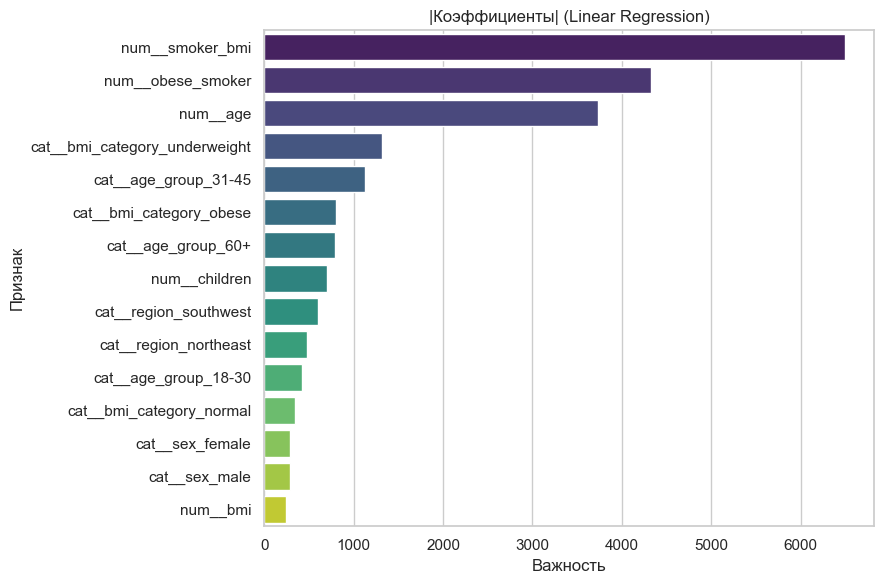

,feature,importance
4,num__smoker_bmi,6496.6734
6,num__obese_smoker,4326.7279
0,num__age,3734.3087
19,cat__bmi_category_underweight,1318.3809
21,cat__age_group_31-45,1121.0987
17,cat__bmi_category_obese,804.4560
23,cat__age_group_60+,790.4858
2,num__children,695.6349
15,cat__region_southwest,599.8783
12,cat__region_northeast,480.6935


In [10]:
prep_fitted = best_reg_pipe.named_steps['prep']
feature_names = prep_fitted.get_feature_names_out()
model_fitted = best_reg_pipe.named_steps['model']

if hasattr(model_fitted, 'feature_importances_'):
    importances = model_fitted.feature_importances_
    title = f'Важности признаков ({best_reg_name})'
else:
    importances = np.abs(model_fitted.coef_)
    title = f'|Коэффициенты| ({best_reg_name})'

fi = (pd.DataFrame({'feature': feature_names, 'importance': importances})
        .sort_values('importance', ascending=False).head(15))
plt.figure(figsize=(9, 6))
sns.barplot(data=fi, x='importance', y='feature', palette='viridis')
plt.title(title); plt.xlabel('Важность'); plt.ylabel('Признак')
plt.tight_layout(); plt.show()
fi.round(4)

## 11. Дополнительный эксперимент: прогноз без feature engineering

Чтобы показать пользу инженерных признаков, обучим те же модели на сырых признаках (6 столбцов).


In [11]:
raw_features = ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
X_raw = df[raw_features]
y_raw = df['charges']
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=RANDOM_STATE,
)
pre_raw = make_preprocessor(X_tr_r)

raw_results = []
for name, m in [('Linear Regression', LinearRegression()),
                ('Ridge', Ridge(alpha=gs_ridge.best_params_['model__alpha'], random_state=RANDOM_STATE)),
                ('Random Forest', RandomForestRegressor(
                    n_estimators=gs_rf.best_params_['model__n_estimators'],
                    max_depth=gs_rf.best_params_['model__max_depth'],
                    min_samples_leaf=gs_rf.best_params_['model__min_samples_leaf'],
                    random_state=RANDOM_STATE))]:
    pipe = Pipeline([('prep', pre_raw), ('model', m)])
    res, _ = eval_regression(name, pipe, X_tr_r, y_tr_r, X_te_r, y_te_r, cv)
    raw_results.append(res)
raw_df = pd.DataFrame(raw_results)
print('Без feature engineering:')
raw_df.round(3)

Без feature engineering:


,Model,MAE,RMSE,R2,CV_R2
0,Linear Regression,4177.046,5956.343,0.807,0.723
1,Ridge,4218.342,5996.870,0.804,0.723
2,Random Forest,2402.602,4302.916,0.899,0.840


In [12]:
compare = pd.DataFrame({
    'Без FE — R²': raw_df.set_index('Model')['R2'],
    'С  FE — R²': regression_results_df.set_index('Model')['R2'],
    'Без FE — MAE': raw_df.set_index('Model')['MAE'],
    'С  FE — MAE': regression_results_df.set_index('Model')['MAE'],
}).round(3)
compare

,Без FE — R²,С FE — R²,Без FE — MAE,С FE — MAE
Model,,,,
Linear Regression,0.807,0.906,4177.046,2266.515
Ridge,0.804,0.907,4218.342,2273.136
Random Forest,0.899,0.899,2402.602,2405.145


# Итоговые выводы

В основной задаче регрессии прогнозировалась величина расходов страховой `charges` (в долларах) — непрерывная неотрицательная переменная. Для этого использовались 6 исходных анкетных признаков (`age`, `sex`, `bmi`, `children`, `smoker`, `region`) и 7 инженерных признаков, сконструированных по итогам EDA (`smoker_bmi`, `obese_smoker`, `smoker_age`, `bmi_category`, `age_group`, `has_children`, `smoker_bin`).

Модели сравнивались по метрикам:

- **MAE** — средняя ошибка прогноза в долларах;
- **RMSE** — ошибка с усиленным штрафом за крупные промахи;
- **R²** — доля объяснённой вариации `charges`;
- **CV R²** — устойчивая 5-fold кросс-валидированная оценка R² на train.

Наиболее информативными признаками ожидаемо являются `smoker_bmi`, `obese_smoker` и `age`, потому что они отражают ключевые драйверы расходов — курение, ожирение и возрастной риск. Дополнительный эксперимент без feature engineering показывает, что без инженерных признаков качество линейных моделей заметно снижается (R² падает с ~0.91 до ~0.81), тогда как Random Forest сохраняет качество — деревья сами находят нелинейные взаимодействия.
